# Test Notebook

This notebook is a temporary sandbox for debugging, validation, and small experiments.

It is **not** part of the official research workflow.  
Any reusable logic tested here should later be moved into:

- `src/` for production code
- formal notebooks for analysis
- `docs/` for methodology notes

## Current Purpose
Use this notebook to inspect pipeline outputs, test fixes, validate joins, and investigate suspicious values.

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

In [13]:
BASE_DIR = Path("..") 
DATA_DIR = BASE_DIR / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

sales_path = INTERIM_DIR / "01_sales_index.csv"
offerings_path = INTERIM_DIR / "02_auction_offerings.csv"
qty_path = INTERIM_DIR / "03_quantity_sold.csv"
weather_path = INTERIM_DIR / "09_weather_features.csv"
preprocessed_path = PROCESSED_DIR / "tea_preprocessed.csv"

sales = pd.read_csv(sales_path)
offerings = pd.read_csv(offerings_path)
qty = pd.read_csv(qty_path)
weather = pd.read_csv(weather_path)
tea = pd.read_csv(preprocessed_path)

print("sales:", sales.shape)
print("offerings:", offerings.shape)
print("qty:", qty.shape)
print("weather:", weather.shape)
print("tea:", tea.shape)

sales: (25, 108)
offerings: (225, 7)
qty: (25, 32)
weather: (100, 61)
tea: (2913, 182)


In [14]:
def quick_check(df, name):
    print(f"\\n=== {name} ===")
    print("Shape:", df.shape)
    print("\\nColumns:")
    print(df.columns.tolist()[:20], "..." if len(df.columns) > 20 else "")
    print("\\nHead:")
    display(df.head())

quick_check(sales, "sales")
quick_check(offerings, "offerings")
quick_check(qty, "qty")
quick_check(weather, "weather")
quick_check(tea, "tea")

\n=== sales ===
Shape: (25, 108)
\nColumns:
['sale_id', 'sale_number', 'sale_date_raw', 'sale_year', 'sale_month', 'source_file', 'extracted_at', 'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity', 'settlement_10pct', 'settlement_buyers', 'settlement_sellers', 'commentary', 'sentiment_overall', 'sentiment_ex_estate', 'sentiment_low_grown', 'western_nuwara_eliya_weather_desc', 'western_nuwara_eliya_weather_score'] ...
\nHead:


,sale_id,sale_number,sale_date_raw,sale_year,sale_month,source_file,extracted_at,total_lots,total_kgs,reprint_lots,reprint_quantity,settlement_10pct,settlement_buyers,settlement_sellers,commentary,sentiment_overall,sentiment_ex_estate,sentiment_low_grown,western_nuwara_eliya_weather_desc,western_nuwara_eliya_weather_score,uva_udapussellawa_weather_desc,uva_udapussellawa_weather_score,low_grown_weather_desc,low_grown_weather_score,crop_notes,avg_weather_severity,crop_nuwara_eliya_trend,crop_western_trend,crop_uva_trend,crop_low_grown_trend,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,fx_usd_2026,fx_usd_2025,fx_usd_2024,fx_gbp_2026,fx_gbp_2025,fx_gbp_2024,fx_eur_2026,fx_eur_2025,fx_eur_2024,fx_jpy_2026,fx_jpy_2025,fx_jpy_2024,gross_lkr_weekly_uva_high_2026,gross_lkr_weekly_uva_high_2025,gross_lkr_todate_uva_high_2026,gross_lkr_todate_uva_high_2025,gross_lkr_weekly_western_high_2026,gross_lkr_weekly_western_high_2025,gross_lkr_todate_western_high_2026,gross_lkr_todate_western_high_2025,gross_lkr_weekly_ctc_high_2026,gross_lkr_weekly_ctc_high_2025,gross_lkr_todate_ctc_high_2026,gross_lkr_todate_ctc_high_2025,gross_lkr_weekly_high_summary_2026,gross_lkr_weekly_high_summary_2025,gross_lkr_todate_high_summary_2026,gross_lkr_todate_high_summary_2025,gross_lkr_weekly_uva_medium_2026,gross_lkr_weekly_uva_medium_2025,gross_lkr_todate_uva_medium_2026,gross_lkr_todate_uva_medium_2025,gross_lkr_weekly_western_medium_2026,gross_lkr_weekly_western_medium_2025,gross_lkr_todate_western_medium_2026,gross_lkr_todate_western_medium_2025,gross_lkr_weekly_ctc_medium_2026,gross_lkr_weekly_ctc_medium_2025,gross_lkr_todate_ctc_medium_2026,gross_lkr_todate_ctc_medium_2025,gross_lkr_weekly_medium_summary_2026,gross_lkr_weekly_medium_summary_2025,gross_lkr_todate_medium_summary_2026,gross_lkr_todate_medium_summary_2025,gross_lkr_weekly_orthodox_low_2026,gross_lkr_weekly_orthodox_low_2025,gross_lkr_todate_orthodox_low_2026,gross_lkr_todate_orthodox_low_2025,gross_lkr_weekly_ctc_low_2026,gross_lkr_weekly_ctc_low_2025,gross_lkr_todate_ctc_low_2026,gross_lkr_todate_ctc_low_2025,gross_lkr_weekly_low_summary_2026,gross_lkr_weekly_low_summary_2025,gross_lkr_todate_low_summary_2026,gross_lkr_todate_low_summary_2025,gross_lkr_weekly_total_2026,gross_lkr_weekly_total_2025,gross_lkr_todate_total_2026,gross_lkr_todate_total_2025,sl_production_mkgs,sl_production_yoy_variance
0,SALE_34_2025,34,01ST/02ND September 2025,2025,September,Sale of 1 & 2 September 2025.pdf,2026-03-21T02:19:42,10619,5105188,1039,503557,04/09/2025,08/09/2025,09/09/2025,Auctionofferingsdeclinedfurtherandtotalled5.1M...,0.2432,0.2432,0.0,Bright mornings and evening showers were repor...,3,The Uva and Uda Pussellawa regions reported su...,3,average for the month recorded an increase of ...,3,AND WEATHER FOR THE PERIOD 27 August - 01 Sept...,3.00,1.0,1.0,1.0,1.0,165981.0,82693.0,7111185.0,4186795.0,4541661.0,5030855.0,166249998.0,158312296.0,20000.0,96180.0,1615231.0,1433250.0,4727642.0,5209728.0,174976414.0,163932341.0,298.30,296.36,317.96,402.18,389.53,399.24,347.91,329.29,341.98,2.02,2.03,2.16,1078.53,1155.32,1038.76,1114.09,1159.31,1163.53,1093.72,1192.96,1101.42,1000.1,1071.21,1106.24,1128.35,1160.69,1075.71,1167.57,1097.71,1095.6,1068.68,1144.57,1015.67,1012.61,1004.38,1070.98,927.54,949.03,940.02,978.34,1039.68,1038.77,1025.62,1096.09,1314.25,1304.65,1260.54,1380.88,976.92,948.61,980.03,1002.99,1289.61,1280.84,1245.12,1356.55,1221.77,1212.16,1172.55,1271.55,NaN,NaN
1,SALE_06_2026,6,10TH/11TH February 2026,2026,February,Sale of 10 & 11 February 2026.pdf,2026-03-21T02:19:43,12252,5949847,2604,1265688,13/02/2026,17/02/2026,

\n=== offerings ===
Shape: (225, 7)
\nColumns:
['sale_id', 'category', 'qty_mkgs', 'demand_label', 'demand_score', 'lots', 'kgs'] 
\nHead:


,sale_id,category,qty_mkgs,demand_label,demand_score,lots,kgs
0,SALE_34_2025,ex_estate,0.64,good,4,672.0,644791.0
1,SALE_34_2025,high_medium,0.57,good,4,1381.0,575134.0
2,SALE_34_2025,leafy,0.74,fair,3,1947.0,744017.0
3,SALE_34_2025,semi_leafy,0.58,fair,3,1410.0,585645.0
4,SALE_34_2025,tippy,0.82,fair,3,1791.0,818511.0


\n=== qty ===
Shape: (25, 32)
\nColumns:
['sale_id', 'sale_number', 'sale_year', 'sale_month', 'private_sales_weekly_2026', 'private_sales_weekly_2025', 'private_sales_todate_2026', 'private_sales_todate_2025', 'public_auction_weekly_2026', 'public_auction_weekly_2025', 'public_auction_todate_2026', 'public_auction_todate_2025', 'forward_contracts_weekly_2026', 'forward_contracts_weekly_2025', 'forward_contracts_todate_2026', 'forward_contracts_todate_2025', 'total_sold_weekly_2026', 'total_sold_weekly_2025', 'total_sold_todate_2026', 'total_sold_todate_2025'] ...
\nHead:


,sale_id,sale_number,sale_year,sale_month,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,fx_usd_2026,fx_usd_2025,fx_usd_2024,fx_gbp_2026,fx_gbp_2025,fx_gbp_2024,fx_eur_2026,fx_eur_2025,fx_eur_2024,fx_jpy_2026,fx_jpy_2025,fx_jpy_2024
0,SALE_34_2025,34,2025,September,165981.0,82693.0,7111185.0,4186795.0,4541661.0,5030855.0,166249998.0,158312296.0,20000.0,96180.0,1615231.0,1433250.0,4727642.0,5209728.0,174976414.0,163932341.0,298.30,296.36,317.96,402.18,389.53,399.24,347.91,329.29,341.98,2.02,2.03,2.16
1,SALE_06_2026,6,2026,February,167226.0,245835.0,1119831.0,1177536.0,4898035.0,5185038.0,24012876.0,25587189.0,41600.0,50070.0,191600.0,339970.0,5106861.0,5480943.0,25324307.0,27104695.0,305.76,292.79,308.56,417.26,360.20,387.69,362.86,299.73,330.69,1.95,1.91,2.07
2,SALE_10_2026,10,2026,March,196032.0,305419.0,2297136.0,2052407.0,4063437.0,4624724.0,42324532.0,44598576.0,34000.0,62820.0,370560.0,614336.0,4293469.0,4992963.0,44621668.0,47265319.0,307.18,291.25,306.06,411.75,374.66,386.49,355.81,313.87,330.31,1.93,1.96,2.02
3,SALE_44_2025,44,2025,November,134264.0,173299.0,9033346.0,5665178.0,4605134.0,4870545.0,211071443.0,205924381.0,20000.0,63050.0,2085259.0,2148336.0,4759398.0,5106894.0,222190048.0,213737895.0,300.50,288.54,321.59,349.30,371.41,395.57,345.78,309.42,342.73,1.93,1.86,2.13
4,SALE_02_2026,2,2026,January,174966.0,77364.0,174966.0,77364.0,4751955.0,5287479.0,4751955.0,5287479.0,22000.0,15000.0,22000.0,15000.0,4948921.0,5379843.0,4948921.0,5379843.0,305.53,290.74,291.32,408.91,352.54,363.13,354.82,297.76,300.65,1.92,1.83,1.83


\n=== weather ===
Shape: (100, 61)
\nColumns:
['sale_id', 'auction_date', 'region', 'region_label', 'lat', 'lon', 'pdf_source', 'text_condition_score', 'text_crop_change', 'text_has_rain', 'text_has_mist', 'text_has_bright', 'text_has_thunder', 'text_keywords', 'text_raw_summary', 'temperature_2m_max_mean', 'temperature_2m_max_max', 'temperature_2m_max_min', 'temperature_2m_min_mean', 'temperature_2m_min_max'] ...
\nHead:


,sale_id,auction_date,region,region_label,lat,lon,pdf_source,text_condition_score,text_crop_change,text_has_rain,text_has_mist,text_has_bright,text_has_thunder,text_keywords,text_raw_summary,temperature_2m_max_mean,temperature_2m_max_max,temperature_2m_max_min,temperature_2m_min_mean,temperature_2m_min_max,temperature_2m_min_min,temperature_2m_mean_mean,temperature_2m_mean_max,temperature_2m_mean_min,precipitation_sum_total,precipitation_sum_max_day,rain_sum_total,rain_sum_max_day,windspeed_10m_max_mean,windspeed_10m_max_max,windspeed_10m_max_min,sunshine_duration_total,sunshine_duration_max_day,et0_fao_evapotranspiration_total,et0_fao_evapotranspiration_max_day,relative_humidity_2m_max_mean,relative_humidity_2m_max_max,relative_humidity_2m_max_min,relative_humidity_2m_min_mean,relative_humidity_2m_min_max,relative_humidity_2m_min_min,fetch_start,fetch_end,precipitation_sum_total_lag1,precipitation_sum_total_lag2,precipitation_sum_total_lag3,rain_sum_total_lag1,rain_sum_total_lag2,rain_sum_total_lag3,temperature_2m_mean_mean_lag1,temperature_2m_mean_mean_lag2,temperature_2m_mean_mean_lag3,sunshine_duration_total_lag1,sunshine_duration_total_lag2,sunshine_duration_total_lag3,relative_humidity_2m_max_max_lag1,relative_humidity_2m_max_max_lag2,relative_humidity_2m_max_max_lag3,text_condition_score_lag1,text_condition_score_lag2,text_condition_score_lag3
0,SALE_01_2026,2026-01-06,low_grown,Low Grown (Matara / Galle belt),6.25,80.3,Sale of 6 & 7 January 2026.pdf,0,decrease,1,0,1,0,sunny|showers,Low Grown\nUva/Udapussellawa Regions regions r...,29.76,31.4,27.3,21.97,22.6,21.0,25.03,25.7,24.4,16.5,5.1,16.5,5.1,12.49,21.0,8.0,233157.27,40437.73,24.01,4.17,98.43,100,97,63.00,76,54,2025-12-30,2026-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SALE_02_2026,2026-01-12,low_grown,Low Grown (Matara / Galle belt),6.25,80.3,Sale of 12 & 13 January 2026.pdf,0,increase,0,0,0,0,NaN,Low Grown\nRegion reported a slight increase.,30.11,31.4,28.6,21.43,22.4,20.5,24.83,25.5,24.0,22.2,13.4,22.2,13.4,11.40,14.7,8.3,229204.50,40760.98,24.90,4.25,98.86,100,97,59.71,69,54,2026-01-05,2026-01-11,16.5,NaN,NaN,16.5,NaN,NaN,25.03,NaN,NaN,233157.27,NaN,NaN,100.0,NaN,NaN,0.0,NaN,NaN
2,SALE_03_2026,2026-01-20,low_grown,Low Grown (Matara / Galle belt),6.25,80.3,Sale of 20 & 21 January 2026_1769052416.pdf,0,decrease,0,0,0,0,NaN,Low Grown\nregions in the week ahead according...,30.50,31.7,28.6,21.33,22.0,20.7,24.79,25.3,24.2,13.1,5.1,13.1,5.1,11.61,13.3,9.4,285462.33,42020.40,28.41,4.70,99.29,100,97,56.00,68,49,2026-01-13,2026-01-19,22.2,16.5,NaN,22.2,16.5,NaN,24.83,25.03,NaN,229204.50,233157.27,NaN,100.0,100.0,NaN,0.0,0.0,NaN
3,SALE_04_2026,2026-01-27,low_grown,Low Grown (Matara / Galle belt),6.25,80.3,Sale of 27 & 28 January 2026.pdf,-1,unknown,0,1,1,0,sunny|misty|mist,Low Growns\nSunny weather conditions were reco...,30.84,32.2,28.4,20.50,22.4,19.5,24.81,25.7,23.9,10.6,5.9,10.6,5.9,10.89,13.3,7.5,290577.02,42111.10,31.04,4.81,98.57,100,96,49.00,63,41,2026-01-20,2026-01-26,13.1,22.2,16.5,13.1,22.2,16.5,24.79,24.83,25.03,285462.33,229204.50,233157.27,100.0,100.0,100.0,0.0,0.0,0.0
4,SALE_05_2026,2026-02-02,low_grown,Low Grown (Matara / Galle belt),6.25,80.3,Sale of 2 & 3 February 2026.pdf,0,unknown,0,0,0,0,NaN,Low Grown\nNuwara Eliya and,31.16,31.8,30.1,21.40,22.4,20.2,24.99,25.7,24.4,40.5,14.2,40.5,14.2,11.01,13.5,7.5,267568.92,42229.17,26.60,4.56,99.00,100,97,56.43,62,46,2026-01-26,2026-02-01,10.6,13.1,22.2,10.6,13.1,22.2,24.81,24.79,24.83,290577.02,285462.33,229204.50,100.0,100.0,100.0,-1.0,0.0,0.0


\n=== tea ===
Shape: (2913, 182)
\nColumns:
['sale_id', 'sale_number', 'sale_year', 'sale_month', 'sale_date_raw', 'table_source', 'elevation', 'category_type', 'grade', 'tier', 'category', 'price_lo_lkr', 'price_hi_lkr', 'price_mid_lkr', 'price_range_lkr', 'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity', 'sentiment_overall'] ...
\nHead:


,sale_id,sale_number,sale_year,sale_month,sale_date_raw,table_source,elevation,category_type,grade,tier,category,price_lo_lkr,price_hi_lkr,price_mid_lkr,price_range_lkr,total_lots,total_kgs,reprint_lots,reprint_quantity,sentiment_overall,sentiment_ex_estate,sentiment_low_grown,western_nuwara_eliya_weather_score,uva_udapussellawa_weather_score,low_grown_weather_score,avg_weather_severity,crop_nuwara_eliya_trend,crop_western_trend,crop_uva_trend,crop_low_grown_trend,sl_production_mkgs,fx_usd_2026,fx_usd_2025,fx_gbp_2026,fx_gbp_2025,fx_eur_2026,fx_eur_2025,fx_jpy_2026,fx_jpy_2025,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,volume_yoy_change_pct,dust__demand_score,ex_estate__demand_score,leafy__demand_score,off_grade__demand_score,premium_flowery__demand_score,semi_leafy__demand_score,dust__qty_mkgs,ex_estate__qty_mkgs,high_medium__qty_mkgs,leafy__qty_mkgs,off_grade__qty_mkgs,premium_flowery__qty_mkgs,semi_leafy__qty_mkgs,tippy__qty_mkgs,total__qty_mkgs,low_grown__precipitation_sum_total,nuwara_eliya__precipitation_sum_total,uva_udapussellawa__precipitation_sum_total,western_high__precipitation_sum_total,low_grown__precipitation_sum_total_lag1,nuwara_eliya__precipitation_sum_total_lag1,uva_udapussellawa__precipitation_sum_total_lag1,western_high__precipitation_sum_total_lag1,low_grown__precipitation_sum_total_lag2,nuwara_eliya__precipitation_sum_total_lag2,uva_udapussellawa__precipitation_sum_total_lag2,western_high__precipitation_sum_total_lag2,low_grown__precipitation_sum_total_lag3,nuwara_eliya__precipitation_sum_total_lag3,uva_udapussellawa__precipitation_sum_total_lag3,western_high__precipitation_sum_total_lag3,low_grown__rain_sum_total_lag1,nuwara_eliya__rain_sum_total_lag1,uva_udapussellawa__rain_sum_total_lag1,western_high__rain_sum_total_lag1,low_grown__rain_sum_total_lag2,nuwara_eliya__rain_sum_total_lag2,uva_udapussellawa__rain_sum_total_lag2,western_high__rain_sum_total_lag2,low_grown__rain_sum_total_lag3,nuwara_eliya__rain_sum_total_lag3,uva_udapussellawa__rain_sum_total_lag3,western_high__rain_sum_total_lag3,uva_udapussellawa__relative_humidity_2m_max_max,western_high__relative_humidity_2m_max_max,low_grown__relative_humidity_2m_max_mean,nuwara_eliya__relative_humidity_2m_max_mean,uva_udapussellawa__relative_humidity_2m_max_mean,western_high__relative_humidity_2m_max_mean,low_grown__relative_humidity_2m_min_mean,nuwara_eliya__relative_humidity_2m_min_mean,uva_udapussellawa__relative_humidity_2m_min_mean,western_high__relative_humidity_2m_min_mean,low_grown__sunshine_duration_total,nuwara_eliya__sunshine_duration_total,uva_udapussellawa__sunshine_duration_total,western_high__sunshine_duration_total,low_grown__sunshine_duration_total_lag1,nuwara_eliya__sunshine_duration_total_lag1,uva_udapussellawa__sunshine_duration_total_lag1,western_high__sunshine_duration_total_lag1,low_grown__sunshine_duration_total_lag2,nuwara_eliya__sunshine_duration_total_lag2,uva_udapussellawa__sunshine_duration_total_lag2,western_high__sunshine_duration_total_lag2,low_grown__sunshine_duration_total_lag3,nuwara_eliya__sunshine_duration_total_lag3,uva_udapussellawa__sunshine_duration_total_lag3,western_high__sunshine_duration_total_lag3,low_grown__temperature_2m_mean_mean,nuwara_eliya__temperature_2m_mean_mean,uva_udapussellawa__temperature_2m_mean_mean,western_high__temperature_2m_mean_mean,low_grown__temperature_2m_mean_mean_lag1,nuwara_eliya__temperature_2m_mean_mean_lag1,uva_udapussellawa__temperature_2m_mean_mean_lag1,western_high__temperature_2m_mean_mean_lag1,low_grown__temperature_2m_mean_mean_lag2,nuwara_eliya__temperature_2m_mean_mean_lag2,uva_udapussellawa__tem

In [15]:
def missing_summary(df, name, top_n=20):
    print(f"\\n=== Missing values: {name} ===")
    miss = df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0].head(top_n)
    display(miss.to_frame("missing_count"))

def duplicate_check(df, subset, name):
    dup_count = df.duplicated(subset=subset).sum()
    print(f"{name} duplicate rows for {subset}: {dup_count}")

missing_summary(sales, "sales")
missing_summary(weather, "weather")
missing_summary(tea, "tea")

duplicate_check(sales, ["sale_id"], "sales")
duplicate_check(qty, ["sale_id"], "qty")
duplicate_check(weather, ["sale_id"], "weather")

\n=== Missing values: sales ===


,missing_count
sl_production_yoy_variance,24
sl_production_mkgs,20
gross_lkr_todate_low_summary_2025,18
gross_lkr_todate_low_summary_2026,18
gross_lkr_weekly_ctc_low_2025,18
gross_lkr_weekly_ctc_low_2026,18
gross_lkr_todate_ctc_low_2025,18
gross_lkr_todate_ctc_low_2026,18
gross_lkr_todate_orthodox_low_2025,18
gross_lkr_todate_orthodox_low_2026,18


\n=== Missing values: weather ===


,missing_count
text_keywords,14
relative_humidity_2m_max_max_lag3,12
text_condition_score_lag3,12
temperature_2m_mean_mean_lag3,12
sunshine_duration_total_lag3,12
precipitation_sum_total_lag3,12
rain_sum_total_lag3,12
temperature_2m_mean_mean_lag2,8
precipitation_sum_total_lag2,8
text_condition_score_lag2,8


\n=== Missing values: tea ===


,missing_count
tier,1617
grade,1125
crop_nuwara_eliya_trend,484
crop_western_trend,484
crop_uva_trend,484
crop_low_grown_trend,484
price_range_lkr,219
price_hi_lkr,219
price_lo_lkr,141
price_mid_lkr,141


sales duplicate rows for ['sale_id']: 0
qty duplicate rows for ['sale_id']: 0
weather duplicate rows for ['sale_id']: 75


In [16]:
sales_ids = set(sales["sale_id"].dropna().astype(str))
qty_ids = set(qty["sale_id"].dropna().astype(str))
weather_ids = set(weather["sale_id"].dropna().astype(str))

print("sale_ids in sales not in qty:", len(sales_ids - qty_ids))
print("sale_ids in qty not in sales:", len(qty_ids - sales_ids))
print("sale_ids in sales not in weather:", len(sales_ids - weather_ids))
print("sale_ids in weather not in sales:", len(weather_ids - sales_ids))

print("\\nSample unmatched sales -> qty:")
print(list(sales_ids - qty_ids)[:10])

print("\\nSample unmatched sales -> weather:")
print(list(sales_ids - weather_ids)[:10])

sale_ids in sales not in qty: 0
sale_ids in qty not in sales: 0
sale_ids in sales not in weather: 0
sale_ids in weather not in sales: 0
\nSample unmatched sales -> qty:
[]
\nSample unmatched sales -> weather:
[]


In [17]:
# Example: inspect malformed sale IDs
suspect_sales = sales[sales["sale_id"].astype(str).str.contains("UNKNOWN", na=False)]
display(suspect_sales)

# Example: suspicious price rows
if "price_mid_lkr" in tea.columns:
    suspicious_prices = tea[(tea["price_mid_lkr"] <= 0) | (tea["price_mid_lkr"] > 6000)]
    display(suspicious_prices.head(20))

# Example: inspect one sale manually
example_sale = "SALE_03_2026"
display(sales[sales["sale_id"] == example_sale])
display(qty[qty["sale_id"] == example_sale])
display(weather[weather["sale_id"] == example_sale])
display(tea[tea["sale_id"] == example_sale].head())

,sale_id,sale_number,sale_date_raw,sale_year,sale_month,source_file,extracted_at,total_lots,total_kgs,reprint_lots,reprint_quantity,settlement_10pct,settlement_buyers,settlement_sellers,commentary,sentiment_overall,sentiment_ex_estate,sentiment_low_grown,western_nuwara_eliya_weather_desc,western_nuwara_eliya_weather_score,uva_udapussellawa_weather_desc,uva_udapussellawa_weather_score,low_grown_weather_desc,low_grown_weather_score,crop_notes,avg_weather_severity,crop_nuwara_eliya_trend,crop_western_trend,crop_uva_trend,crop_low_grown_trend,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,fx_usd_2026,fx_usd_2025,fx_usd_2024,fx_gbp_2026,fx_gbp_2025,fx_gbp_2024,fx_eur_2026,fx_eur_2025,fx_eur_2024,fx_jpy_2026,fx_jpy_2025,fx_jpy_2024,gross_lkr_weekly_uva_high_2026,gross_lkr_weekly_uva_high_2025,gross_lkr_todate_uva_high_2026,gross_lkr_todate_uva_high_2025,gross_lkr_weekly_western_high_2026,gross_lkr_weekly_western_high_2025,gross_lkr_todate_western_high_2026,gross_lkr_todate_western_high_2025,gross_lkr_weekly_ctc_high_2026,gross_lkr_weekly_ctc_high_2025,gross_lkr_todate_ctc_high_2026,gross_lkr_todate_ctc_high_2025,gross_lkr_weekly_high_summary_2026,gross_lkr_weekly_high_summary_2025,gross_lkr_todate_high_summary_2026,gross_lkr_todate_high_summary_2025,gross_lkr_weekly_uva_medium_2026,gross_lkr_weekly_uva_medium_2025,gross_lkr_todate_uva_medium_2026,gross_lkr_todate_uva_medium_2025,gross_lkr_weekly_western_medium_2026,gross_lkr_weekly_western_medium_2025,gross_lkr_todate_western_medium_2026,gross_lkr_todate_western_medium_2025,gross_lkr_weekly_ctc_medium_2026,gross_lkr_weekly_ctc_medium_2025,gross_lkr_todate_ctc_medium_2026,gross_lkr_todate_ctc_medium_2025,gross_lkr_weekly_medium_summary_2026,gross_lkr_weekly_medium_summary_2025,gross_lkr_todate_medium_summary_2026,gross_lkr_todate_medium_summary_2025,gross_lkr_weekly_orthodox_low_2026,gross_lkr_weekly_orthodox_low_2025,gross_lkr_todate_orthodox_low_2026,gross_lkr_todate_orthodox_low_2025,gross_lkr_weekly_ctc_low_2026,gross_lkr_weekly_ctc_low_2025,gross_lkr_todate_ctc_low_2026,gross_lkr_todate_ctc_low_2025,gross_lkr_weekly_low_summary_2026,gross_lkr_weekly_low_summary_2025,gross_lkr_todate_low_summary_2026,gross_lkr_todate_low_summary_2025,gross_lkr_weekly_total_2026,gross_lkr_weekly_total_2025,gross_lkr_todate_total_2026,gross_lkr_todate_total_2025,sl_production_mkgs,sl_production_yoy_variance


,sale_id,sale_number,sale_year,sale_month,sale_date_raw,table_source,elevation,category_type,grade,tier,category,price_lo_lkr,price_hi_lkr,price_mid_lkr,price_range_lkr,total_lots,total_kgs,reprint_lots,reprint_quantity,sentiment_overall,sentiment_ex_estate,sentiment_low_grown,western_nuwara_eliya_weather_score,uva_udapussellawa_weather_score,low_grown_weather_score,avg_weather_severity,crop_nuwara_eliya_trend,crop_western_trend,crop_uva_trend,crop_low_grown_trend,sl_production_mkgs,fx_usd_2026,fx_usd_2025,fx_gbp_2026,fx_gbp_2025,fx_eur_2026,fx_eur_2025,fx_jpy_2026,fx_jpy_2025,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,volume_yoy_change_pct,dust__demand_score,ex_estate__demand_score,leafy__demand_score,off_grade__demand_score,premium_flowery__demand_score,semi_leafy__demand_score,dust__qty_mkgs,ex_estate__qty_mkgs,high_medium__qty_mkgs,leafy__qty_mkgs,off_grade__qty_mkgs,premium_flowery__qty_mkgs,semi_leafy__qty_mkgs,tippy__qty_mkgs,total__qty_mkgs,low_grown__precipitation_sum_total,nuwara_eliya__precipitation_sum_total,uva_udapussellawa__precipitation_sum_total,western_high__precipitation_sum_total,low_grown__precipitation_sum_total_lag1,nuwara_eliya__precipitation_sum_total_lag1,uva_udapussellawa__precipitation_sum_total_lag1,western_high__precipitation_sum_total_lag1,low_grown__precipitation_sum_total_lag2,nuwara_eliya__precipitation_sum_total_lag2,uva_udapussellawa__precipitation_sum_total_lag2,western_high__precipitation_sum_total_lag2,low_grown__precipitation_sum_total_lag3,nuwara_eliya__precipitation_sum_total_lag3,uva_udapussellawa__precipitation_sum_total_lag3,western_high__precipitation_sum_total_lag3,low_grown__rain_sum_total_lag1,nuwara_eliya__rain_sum_total_lag1,uva_udapussellawa__rain_sum_total_lag1,western_high__rain_sum_total_lag1,low_grown__rain_sum_total_lag2,nuwara_eliya__rain_sum_total_lag2,uva_udapussellawa__rain_sum_total_lag2,western_high__rain_sum_total_lag2,low_grown__rain_sum_total_lag3,nuwara_eliya__rain_sum_total_lag3,uva_udapussellawa__rain_sum_total_lag3,western_high__rain_sum_total_lag3,uva_udapussellawa__relative_humidity_2m_max_max,western_high__relative_humidity_2m_max_max,low_grown__relative_humidity_2m_max_mean,nuwara_eliya__relative_humidity_2m_max_mean,uva_udapussellawa__relative_humidity_2m_max_mean,western_high__relative_humidity_2m_max_mean,low_grown__relative_humidity_2m_min_mean,nuwara_eliya__relative_humidity_2m_min_mean,uva_udapussellawa__relative_humidity_2m_min_mean,western_high__relative_humidity_2m_min_mean,low_grown__sunshine_duration_total,nuwara_eliya__sunshine_duration_total,uva_udapussellawa__sunshine_duration_total,western_high__sunshine_duration_total,low_grown__sunshine_duration_total_lag1,nuwara_eliya__sunshine_duration_total_lag1,uva_udapussellawa__sunshine_duration_total_lag1,western_high__sunshine_duration_total_lag1,low_grown__sunshine_duration_total_lag2,nuwara_eliya__sunshine_duration_total_lag2,uva_udapussellawa__sunshine_duration_total_lag2,western_high__sunshine_duration_total_lag2,low_grown__sunshine_duration_total_lag3,nuwara_eliya__sunshine_duration_total_lag3,uva_udapussellawa__sunshine_duration_total_lag3,western_high__sunshine_duration_total_lag3,low_grown__temperature_2m_mean_mean,nuwara_eliya__temperature_2m_mean_mean,uva_udapussellawa__temperature_2m_mean_mean,western_high__temperature_2m_mean_mean,low_grown__temperature_2m_mean_mean_lag1,nuwara_eliya__temperature_2m_mean_mean_lag1,uva_udapussellawa__temperature_2m_mean_mean_lag1,western_high__temperature_2m_mean_mean_lag1,low_grown__temperature_2m_mean_mean_lag2,nuwara_eliya__temperature_2m_mean_mean_lag2,uva_udapussellawa__tem

,sale_id,sale_number,sale_date_raw,sale_year,sale_month,source_file,extracted_at,total_lots,total_kgs,reprint_lots,reprint_quantity,settlement_10pct,settlement_buyers,settlement_sellers,commentary,sentiment_overall,sentiment_ex_estate,sentiment_low_grown,western_nuwara_eliya_weather_desc,western_nuwara_eliya_weather_score,uva_udapussellawa_weather_desc,uva_udapussellawa_weather_score,low_grown_weather_desc,low_grown_weather_score,crop_notes,avg_weather_severity,crop_nuwara_eliya_trend,crop_western_trend,crop_uva_trend,crop_low_grown_trend,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,fx_usd_2026,fx_usd_2025,fx_usd_2024,fx_gbp_2026,fx_gbp_2025,fx_gbp_2024,fx_eur_2026,fx_eur_2025,fx_eur_2024,fx_jpy_2026,fx_jpy_2025,fx_jpy_2024,gross_lkr_weekly_uva_high_2026,gross_lkr_weekly_uva_high_2025,gross_lkr_todate_uva_high_2026,gross_lkr_todate_uva_high_2025,gross_lkr_weekly_western_high_2026,gross_lkr_weekly_western_high_2025,gross_lkr_todate_western_high_2026,gross_lkr_todate_western_high_2025,gross_lkr_weekly_ctc_high_2026,gross_lkr_weekly_ctc_high_2025,gross_lkr_todate_ctc_high_2026,gross_lkr_todate_ctc_high_2025,gross_lkr_weekly_high_summary_2026,gross_lkr_weekly_high_summary_2025,gross_lkr_todate_high_summary_2026,gross_lkr_todate_high_summary_2025,gross_lkr_weekly_uva_medium_2026,gross_lkr_weekly_uva_medium_2025,gross_lkr_todate_uva_medium_2026,gross_lkr_todate_uva_medium_2025,gross_lkr_weekly_western_medium_2026,gross_lkr_weekly_western_medium_2025,gross_lkr_todate_western_medium_2026,gross_lkr_todate_western_medium_2025,gross_lkr_weekly_ctc_medium_2026,gross_lkr_weekly_ctc_medium_2025,gross_lkr_todate_ctc_medium_2026,gross_lkr_todate_ctc_medium_2025,gross_lkr_weekly_medium_summary_2026,gross_lkr_weekly_medium_summary_2025,gross_lkr_todate_medium_summary_2026,gross_lkr_todate_medium_summary_2025,gross_lkr_weekly_orthodox_low_2026,gross_lkr_weekly_orthodox_low_2025,gross_lkr_todate_orthodox_low_2026,gross_lkr_todate_orthodox_low_2025,gross_lkr_weekly_ctc_low_2026,gross_lkr_weekly_ctc_low_2025,gross_lkr_todate_ctc_low_2026,gross_lkr_todate_ctc_low_2025,gross_lkr_weekly_low_summary_2026,gross_lkr_weekly_low_summary_2025,gross_lkr_todate_low_summary_2026,gross_lkr_todate_low_summary_2025,gross_lkr_weekly_total_2026,gross_lkr_weekly_total_2025,gross_lkr_todate_total_2026,gross_lkr_todate_total_2025,sl_production_mkgs,sl_production_yoy_variance
11,SALE_03_2026,3,20TH/21ST January 2026,2026,January,Sale of 20 & 21 January 2026_1769052416.pdf,2026-03-21T02:20:00,12472,6349608,480,229010,23/01/2026,27/01/2026,28/01/2026,"Auctionofferingtotalled6.4M/Kgs,upfroma6.0M/Kg...",0.1351,0.1351,0.0,The Western and Nuwara Eliya regions The Weste...,1,Both regions reported sunny mornings and eveni...,3,regions in the week ahead according to the Dep...,3,AND WEATHER FOR THE PERIOD 13 - 19 January 202...,2.33,-1.0,-1.0,-1.0,-1.0,188040.0,154281.0,363006.0,467425.0,4465515.0,3596046.0,9214550.0,8883525.0,42000.0,70720.0,64000.0,182760.0,257440687.0,245787876.0,11652811.0,1760.0,305.95,292.83,317.35,409.54,358.4,400.88,355.14,302.31,344.85,1.92,1.87,2.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.44,NaN


,sale_id,sale_number,sale_year,sale_month,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,fx_usd_2026,fx_usd_2025,fx_usd_2024,fx_gbp_2026,fx_gbp_2025,fx_gbp_2024,fx_eur_2026,fx_eur_2025,fx_eur_2024,fx_jpy_2026,fx_jpy_2025,fx_jpy_2024
11,SALE_03_2026,3,2026,January,188040.0,154281.0,363006.0,467425.0,4465515.0,3596046.0,9214550.0,8883525.0,42000.0,70720.0,64000.0,182760.0,257440687.0,245787876.0,11652811.0,1760.0,305.95,292.83,317.35,409.54,358.4,400.88,355.14,302.31,344.85,1.92,1.87,2.16


,sale_id,auction_date,region,region_label,lat,lon,pdf_source,text_condition_score,text_crop_change,text_has_rain,text_has_mist,text_has_bright,text_has_thunder,text_keywords,text_raw_summary,temperature_2m_max_mean,temperature_2m_max_max,temperature_2m_max_min,temperature_2m_min_mean,temperature_2m_min_max,temperature_2m_min_min,temperature_2m_mean_mean,temperature_2m_mean_max,temperature_2m_mean_min,precipitation_sum_total,precipitation_sum_max_day,rain_sum_total,rain_sum_max_day,windspeed_10m_max_mean,windspeed_10m_max_max,windspeed_10m_max_min,sunshine_duration_total,sunshine_duration_max_day,et0_fao_evapotranspiration_total,et0_fao_evapotranspiration_max_day,relative_humidity_2m_max_mean,relative_humidity_2m_max_max,relative_humidity_2m_max_min,relative_humidity_2m_min_mean,relative_humidity_2m_min_max,relative_humidity_2m_min_min,fetch_start,fetch_end,precipitation_sum_total_lag1,precipitation_sum_total_lag2,precipitation_sum_total_lag3,rain_sum_total_lag1,rain_sum_total_lag2,rain_sum_total_lag3,temperature_2m_mean_mean_lag1,temperature_2m_mean_mean_lag2,temperature_2m_mean_mean_lag3,sunshine_duration_total_lag1,sunshine_duration_total_lag2,sunshine_duration_total_lag3,relative_humidity_2m_max_max_lag1,relative_humidity_2m_max_max_lag2,relative_humidity_2m_max_max_lag3,text_condition_score_lag1,text_condition_score_lag2,text_condition_score_lag3
2,SALE_03_2026,2026-01-20,low_grown,Low Grown (Matara / Galle belt),6.2500,80.3000,Sale of 20 & 21 January 2026_1769052416.pdf,0,decrease,0,0,0,0,NaN,Low Grown\nregions in the week ahead according...,30.50,31.7,28.6,21.33,22.0,20.7,24.79,25.3,24.2,13.1,5.1,13.1,5.1,11.61,13.3,9.4,285462.33,42020.40,28.41,4.70,99.29,100,97,56.00,68,49,2026-01-13,2026-01-19,22.2,16.5,NaN,22.2,16.5,NaN,24.83,25.03,NaN,229204.50,233157.27,NaN,100.0,100.0,NaN,0.0,0.0,NaN
27,SALE_03_2026,2026-01-20,nuwara_eliya,Nuwara Eliya,6.9497,80.7891,Sale of 20 & 21 January 2026_1769052416.pdf,0,maintained,1,0,1,0,bright|showers,Nuwara Eliya Regions\nThe Western and Nuwara E...,19.69,21.5,17.5,9.44,11.2,7.9,14.03,15.3,12.4,1.6,1.6,1.6,1.6,10.34,12.7,5.3,289637.46,41831.21,26.65,4.18,98.00,100,89,53.29,71,38,2026-01-13,2026-01-19,37.0,19.8,NaN,37.0,19.8,NaN,14.54,14.97,NaN,180412.60,211435.05,NaN,100.0,100.0,NaN,1.0,0.0,NaN
52,SALE_03_2026,2026-01-20,uva_udapussellawa,Uva / Uda Pussellawa,6.8700,81.0600,Sale of 20 & 21 January 2026_1769052416.pdf,0,unknown,1,0,1,0,sunny|showers,Uva/Udapussellawa Regions\nBoth regions report...,23.99,24.9,23.2,14.83,16.5,13.4,18.84,19.2,17.8,10.0,3.9,10.0,3.9,11.57,17.8,7.0,279914.05,41674.91,26.89,4.42,97.14,100,92,62.71,73,56,2026-01-13,2026-01-19,60.8,25.7,NaN,60.8,25.7,NaN,19.21,19.89,NaN,185671.86,227316.64,NaN,100.0,100.0,NaN,-2.0,0.0,NaN
77,SALE_03_2026,2026-01-20,western_high,Western High Grown (Maskeliya / Dickoya),6.9271,80.5350,Sale of 20 & 21 January 2026_1769052416.pdf,0,maintained,1,0,1,0,bright|showers,Western/Nuwara Eliya Regions\nThe Western and ...,24.59,26.3,23.6,13.76,15.2,12.2,18.71,19.2,18.4,8.5,6.2,8.5,6.2,9.26,11.7,7.9,291633.41,41904.06,28.54,4.50,94.71,100,89,53.57,72,39,2026-01-13,2026-01-19,44.2,12.3,NaN,44.2,12.3,NaN,19.23,19.66,NaN,208117.34,220573.65,NaN,100.0,100.0,NaN,1.0,0.0,NaN


,sale_id,sale_number,sale_year,sale_month,sale_date_raw,table_source,elevation,category_type,grade,tier,category,price_lo_lkr,price_hi_lkr,price_mid_lkr,price_range_lkr,total_lots,total_kgs,reprint_lots,reprint_quantity,sentiment_overall,sentiment_ex_estate,sentiment_low_grown,western_nuwara_eliya_weather_score,uva_udapussellawa_weather_score,low_grown_weather_score,avg_weather_severity,crop_nuwara_eliya_trend,crop_western_trend,crop_uva_trend,crop_low_grown_trend,sl_production_mkgs,fx_usd_2026,fx_usd_2025,fx_gbp_2026,fx_gbp_2025,fx_eur_2026,fx_eur_2025,fx_jpy_2026,fx_jpy_2025,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,volume_yoy_change_pct,dust__demand_score,ex_estate__demand_score,leafy__demand_score,off_grade__demand_score,premium_flowery__demand_score,semi_leafy__demand_score,dust__qty_mkgs,ex_estate__qty_mkgs,high_medium__qty_mkgs,leafy__qty_mkgs,off_grade__qty_mkgs,premium_flowery__qty_mkgs,semi_leafy__qty_mkgs,tippy__qty_mkgs,total__qty_mkgs,low_grown__precipitation_sum_total,nuwara_eliya__precipitation_sum_total,uva_udapussellawa__precipitation_sum_total,western_high__precipitation_sum_total,low_grown__precipitation_sum_total_lag1,nuwara_eliya__precipitation_sum_total_lag1,uva_udapussellawa__precipitation_sum_total_lag1,western_high__precipitation_sum_total_lag1,low_grown__precipitation_sum_total_lag2,nuwara_eliya__precipitation_sum_total_lag2,uva_udapussellawa__precipitation_sum_total_lag2,western_high__precipitation_sum_total_lag2,low_grown__precipitation_sum_total_lag3,nuwara_eliya__precipitation_sum_total_lag3,uva_udapussellawa__precipitation_sum_total_lag3,western_high__precipitation_sum_total_lag3,low_grown__rain_sum_total_lag1,nuwara_eliya__rain_sum_total_lag1,uva_udapussellawa__rain_sum_total_lag1,western_high__rain_sum_total_lag1,low_grown__rain_sum_total_lag2,nuwara_eliya__rain_sum_total_lag2,uva_udapussellawa__rain_sum_total_lag2,western_high__rain_sum_total_lag2,low_grown__rain_sum_total_lag3,nuwara_eliya__rain_sum_total_lag3,uva_udapussellawa__rain_sum_total_lag3,western_high__rain_sum_total_lag3,uva_udapussellawa__relative_humidity_2m_max_max,western_high__relative_humidity_2m_max_max,low_grown__relative_humidity_2m_max_mean,nuwara_eliya__relative_humidity_2m_max_mean,uva_udapussellawa__relative_humidity_2m_max_mean,western_high__relative_humidity_2m_max_mean,low_grown__relative_humidity_2m_min_mean,nuwara_eliya__relative_humidity_2m_min_mean,uva_udapussellawa__relative_humidity_2m_min_mean,western_high__relative_humidity_2m_min_mean,low_grown__sunshine_duration_total,nuwara_eliya__sunshine_duration_total,uva_udapussellawa__sunshine_duration_total,western_high__sunshine_duration_total,low_grown__sunshine_duration_total_lag1,nuwara_eliya__sunshine_duration_total_lag1,uva_udapussellawa__sunshine_duration_total_lag1,western_high__sunshine_duration_total_lag1,low_grown__sunshine_duration_total_lag2,nuwara_eliya__sunshine_duration_total_lag2,uva_udapussellawa__sunshine_duration_total_lag2,western_high__sunshine_duration_total_lag2,low_grown__sunshine_duration_total_lag3,nuwara_eliya__sunshine_duration_total_lag3,uva_udapussellawa__sunshine_duration_total_lag3,western_high__sunshine_duration_total_lag3,low_grown__temperature_2m_mean_mean,nuwara_eliya__temperature_2m_mean_mean,uva_udapussellawa__temperature_2m_mean_mean,western_high__temperature_2m_mean_mean,low_grown__temperature_2m_mean_mean_lag1,nuwara_eliya__temperature_2m_mean_mean_lag1,uva_udapussellawa__temperature_2m_mean_mean_lag1,western_high__temperature_2m_mean_mean_lag1,low_grown__temperature_2m_mean_mean_lag2,nuwara_eliya__temperature_2m_mean_mean_lag2,uva_udapussellawa__tem

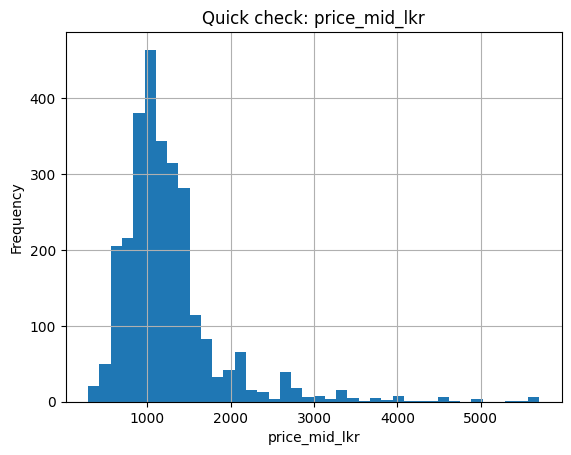

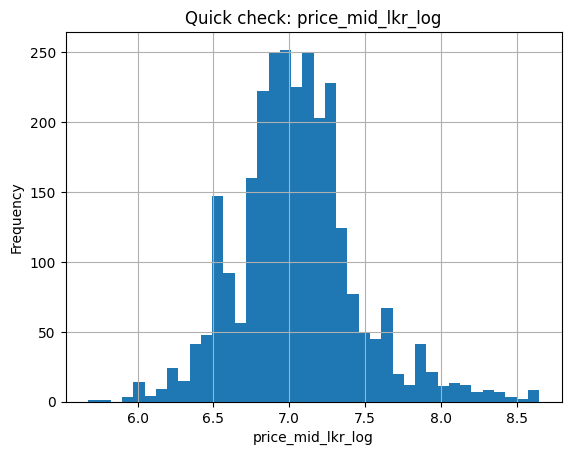

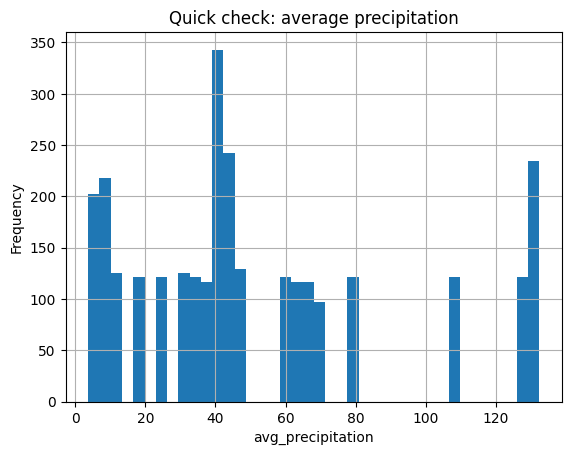

In [18]:
if "price_mid_lkr" in tea.columns:
    tea["price_mid_lkr"].hist(bins=40)
    plt.title("Quick check: price_mid_lkr")
    plt.xlabel("price_mid_lkr")
    plt.ylabel("Frequency")
    plt.show()

if "price_mid_lkr_log" in tea.columns:
    tea["price_mid_lkr_log"].hist(bins=40)
    plt.title("Quick check: price_mid_lkr_log")
    plt.xlabel("price_mid_lkr_log")
    plt.ylabel("Frequency")
    plt.show()

if "all_regions__avg_precipitation" in tea.columns:
    tea["all_regions__avg_precipitation"].hist(bins=40)
    plt.title("Quick check: average precipitation")
    plt.xlabel("avg_precipitation")
    plt.ylabel("Frequency")
    plt.show()

In [19]:
# Example: try a temporary cleaning rule
tmp = tea.copy()

if "elevation" in tmp.columns:
    tmp["elevation_clean"] = (
        tmp["elevation"]
        .astype(str)
        .str.strip()
        .str.title()
    )

display(tmp[["elevation", "elevation_clean"]].drop_duplicates().head(20))

,elevation,elevation_clean
0,high_grown,High_Grown
28,low_grown,Low_Grown
81,medium_grown,Medium_Grown


## Notes

- Keep this notebook temporary and lightweight.
- Do not store final figures here.
- Move stable logic into `src/`.
- Move meaningful analysis into official notebooks.
- Delete or archive obsolete experiments regularly.